<a href="https://colab.research.google.com/github/hansi-2000/HR-Project_ML/blob/main/EMP_Attrition_rate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
## IMPORT LIBRARIES ##

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Import the required function for preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Import train and test split function
from sklearn.model_selection import train_test_split

# Import Classifiers to be used
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

# Import packages to calculate performance of the models
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, roc_auc_score

# To save the model import pickle
import pickle



In [61]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1arzP2ZpZczWWaFjCd9D51b05dJTo7w8z'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1pq5RVhrVYH8f2qXJRgfLpLzio026OvZM'
test = pd.read_csv(test_url)

# Check if the data is loaded correctly
print(train.head())
print(test.head())


   Employee ID  Age  Gender  Years at Company    Job Role  Monthly Income  \
0         8410   31    Male                19   Education            5390   
1        64756   59  Female                 4       Media            5534   
2        30257   24  Female                10  Healthcare            8159   
3        65791   36  Female                 7   Education            3989   
4        65026   56    Male                41   Education            4821   

  Work-Life Balance Job Satisfaction Performance Rating  Number of Promotions  \
0         Excellent           Medium            Average                     2   
1              Poor             High                Low                     3   
2              Good             High                Low                     0   
3              Good             High               High                     1   
4              Fair        Very High            Average                     0   

  Overtime  Distance from Home    Education Level 

In [52]:
emp_data = pd.concat([train, test], ignore_index=True)

emp_data.info()

emp_data.nunique()

emp_data.isnull().sum()
print()

print("Duplicates: ",emp_data.duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74498 entries, 0 to 74497
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Employee ID               74498 non-null  int64 
 1   Age                       74498 non-null  int64 
 2   Gender                    74498 non-null  object
 3   Years at Company          74498 non-null  int64 
 4   Job Role                  74498 non-null  object
 5   Monthly Income            74498 non-null  int64 
 6   Work-Life Balance         74498 non-null  object
 7   Job Satisfaction          74498 non-null  object
 8   Performance Rating        74498 non-null  object
 9   Number of Promotions      74498 non-null  int64 
 10  Overtime                  74498 non-null  object
 11  Distance from Home        74498 non-null  int64 
 12  Education Level           74498 non-null  object
 13  Marital Status            74498 non-null  object
 14  Number of Dependents  

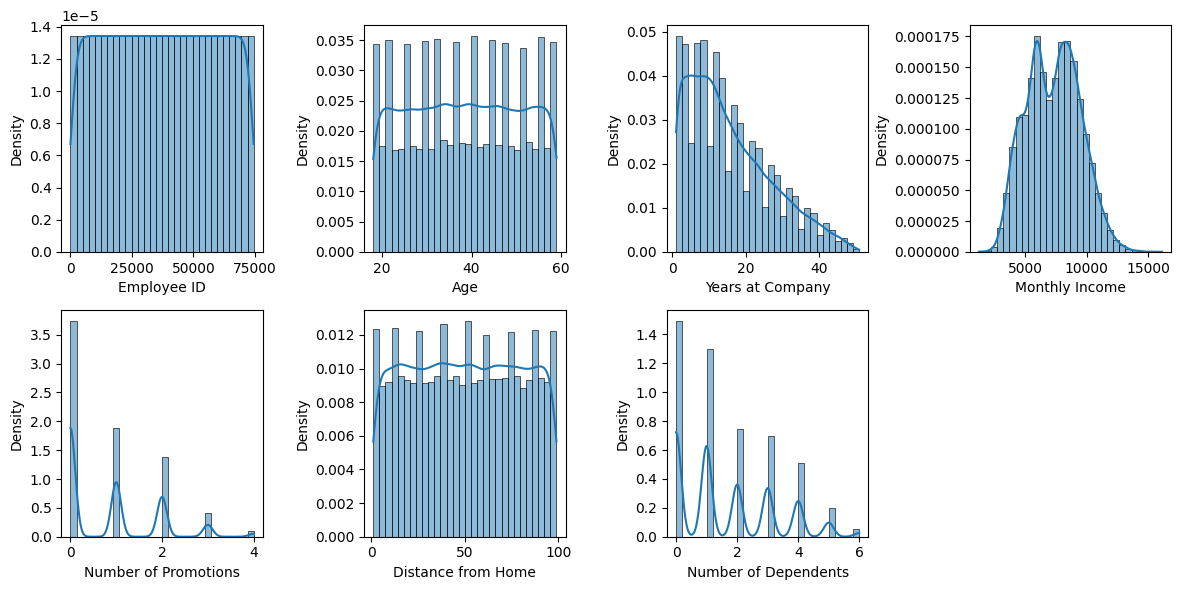

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

emp_eda = emp_data.copy()

# Assuming emp_eda is already defined and contains numeric columns
num_cols_eda = [n for n in emp_eda.columns if emp_eda[n].dtypes != 'O']

# Create a 2x4 grid of subplots (8 subplots total, we'll use 7)
fig, ax = plt.subplots(2, 4, figsize=(12, 6))
ax = ax.flatten()

# Loop over the first 7 numerical columns and create a histogram for each
for i, col in enumerate(num_cols_eda[:7]):  # Limit to 7 columns
    sns.histplot(emp_eda[col], kde=True, stat='density', bins=30, ax=ax[i])

# Hide the 8th subplot (since we only need 7 plots)
ax[7].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


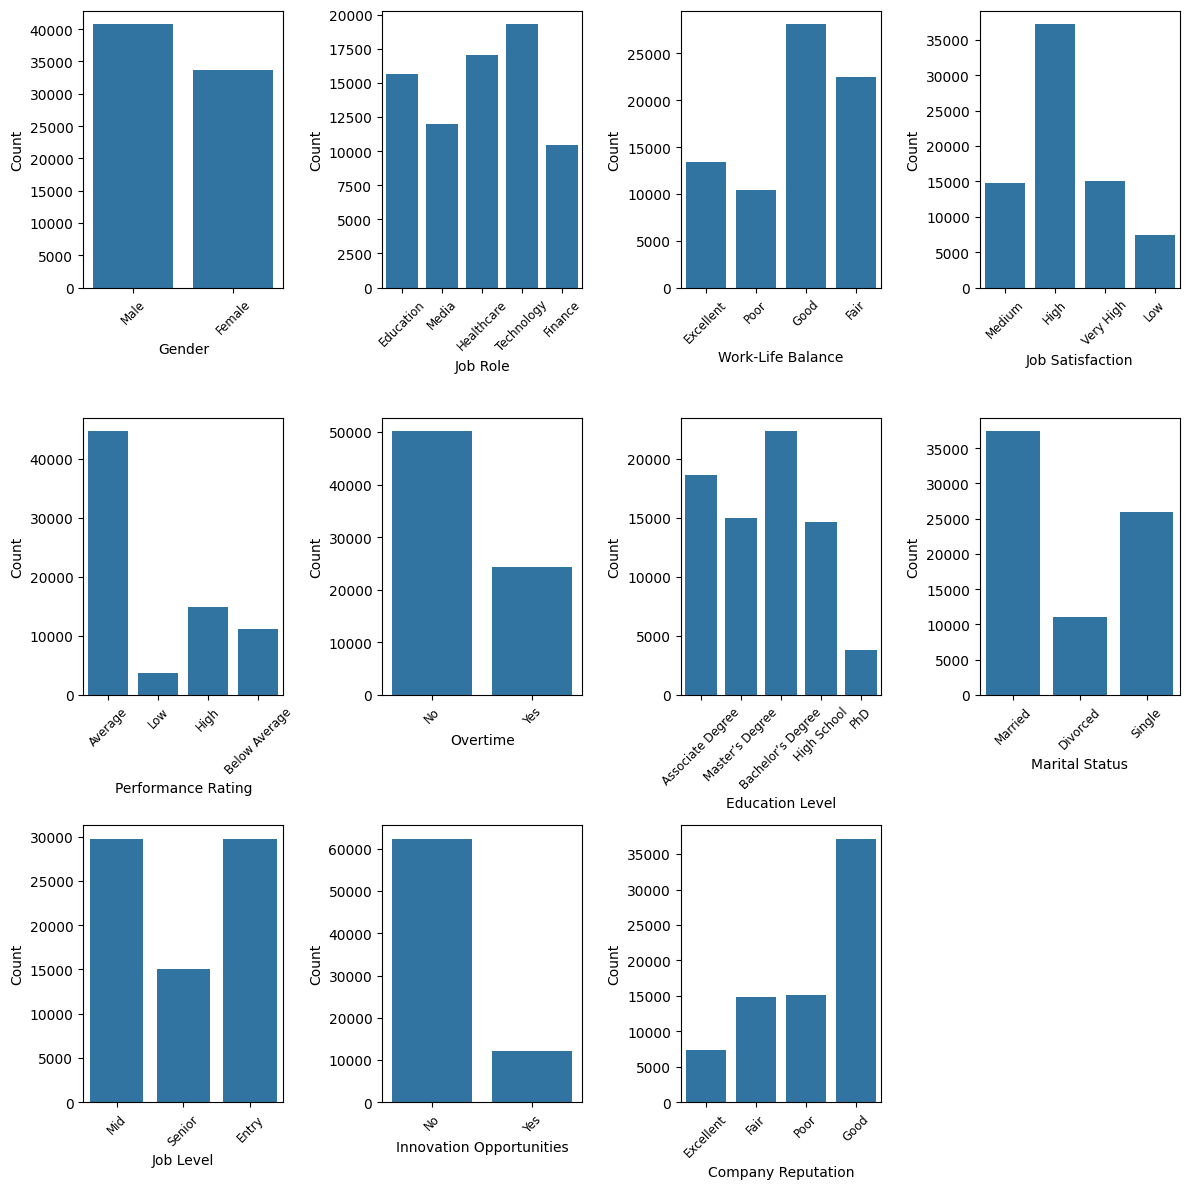

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming emp_eda is already defined and contains categorical columns
cat_cols_eda = [c for c in emp_eda.columns if emp_eda[c].dtypes == 'O']

# Create a 3x4 grid of subplots (12 subplots total)
fig, ax = plt.subplots(3, 4, figsize=(12, 12))
ax = ax.flatten()

# Loop over the first 11 categorical columns and create a countplot for each
for i, col in enumerate(cat_cols_eda[:11]):  # Limit to 11 columns
    sns.countplot(x=col, data=emp_eda, ax=ax[i])
    ax[i].set_ylabel('Count')
    ax[i].tick_params(axis='x', rotation=45, labelsize=8.5)

# Hide the 12th subplot (since we only need 11 plots)
ax[11].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [62]:
import pandas as pd

# Train dataset
train_url = 'https://drive.google.com/uc?export=download&id=1arzP2ZpZczWWaFjCd9D51b05dJTo7w8z'
train = pd.read_csv(train_url)

# Test dataset
test_url = 'https://drive.google.com/uc?export=download&id=1pq5RVhrVYH8f2qXJRgfLpLzio026OvZM'
test = pd.read_csv(test_url)

   Employee ID  Age  Gender  Years at Company    Job Role  Monthly Income  \
0         8410   31    Male                19   Education            5390   
1        64756   59  Female                 4       Media            5534   
2        30257   24  Female                10  Healthcare            8159   
3        65791   36  Female                 7   Education            3989   
4        65026   56    Male                41   Education            4821   

  Work-Life Balance Job Satisfaction Performance Rating  Number of Promotions  \
0         Excellent           Medium            Average                     2   
1              Poor             High                Low                     3   
2              Good             High                Low                     0   
3              Good             High               High                     1   
4              Fair        Very High            Average                     0   

  Overtime  Distance from Home    Education Level 

In [63]:
# emp_data.head()
#print(emp_data.columns)

ordinal_mappings = {
    'Work-Life Balance': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Company Reputation': {'Poor': 1, 'Fair': 2, 'Good': 3, 'Excellent': 4},
    'Job Satisfaction': {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4},
    'Performance Rating': {'Low': 1, 'Below Average': 2, 'Average': 3, 'High': 4},
    'Education Level': {'High School': 1, 'Associate Degree': 2, 'Bachelor’s Degree': 3, 'Master’s Degree': 4, 'PhD': 5},
    'Job Level': {'Entry': 1, 'Mid': 2, 'Senior': 3},
}

for col, mapping in ordinal_mappings.items():
    train[col] = train[col].map(mapping)
    test[col] = test[col].map(mapping)


In [64]:
# print("Unique values in Gender column:", emp_data['Gender'].unique())
binary_columns = ['Innovation Opportunities', 'Overtime', 'Gender', 'Attrition']

binary_mapping = {'No': 0, 'Yes': 1, 'Male': 0, 'Female': 1, 'Stayed':1, 'Left':0}

for col in binary_columns:
    train[col] = train[col].map(binary_mapping)
    test[col] = test[col].map(binary_mapping)

train.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,Overtime,Distance from Home,Education Level,Marital Status,Number of Dependents,Job Level,Company Tenure,Innovation Opportunities,Company Reputation,Attrition
0,8410,31,0,19,Education,5390,4,2,3,2,0,22,2,Married,0,2,89,0,4,1
1,64756,59,1,4,Media,5534,1,3,1,3,0,21,4,Divorced,3,2,21,0,2,1
2,30257,24,1,10,Healthcare,8159,3,3,1,0,0,11,3,Married,3,2,74,0,1,1
3,65791,36,1,7,Education,3989,3,3,4,1,0,27,1,Single,2,2,50,0,3,1
4,65026,56,0,41,Education,4821,2,4,3,0,1,71,1,Divorced,0,3,68,0,2,1


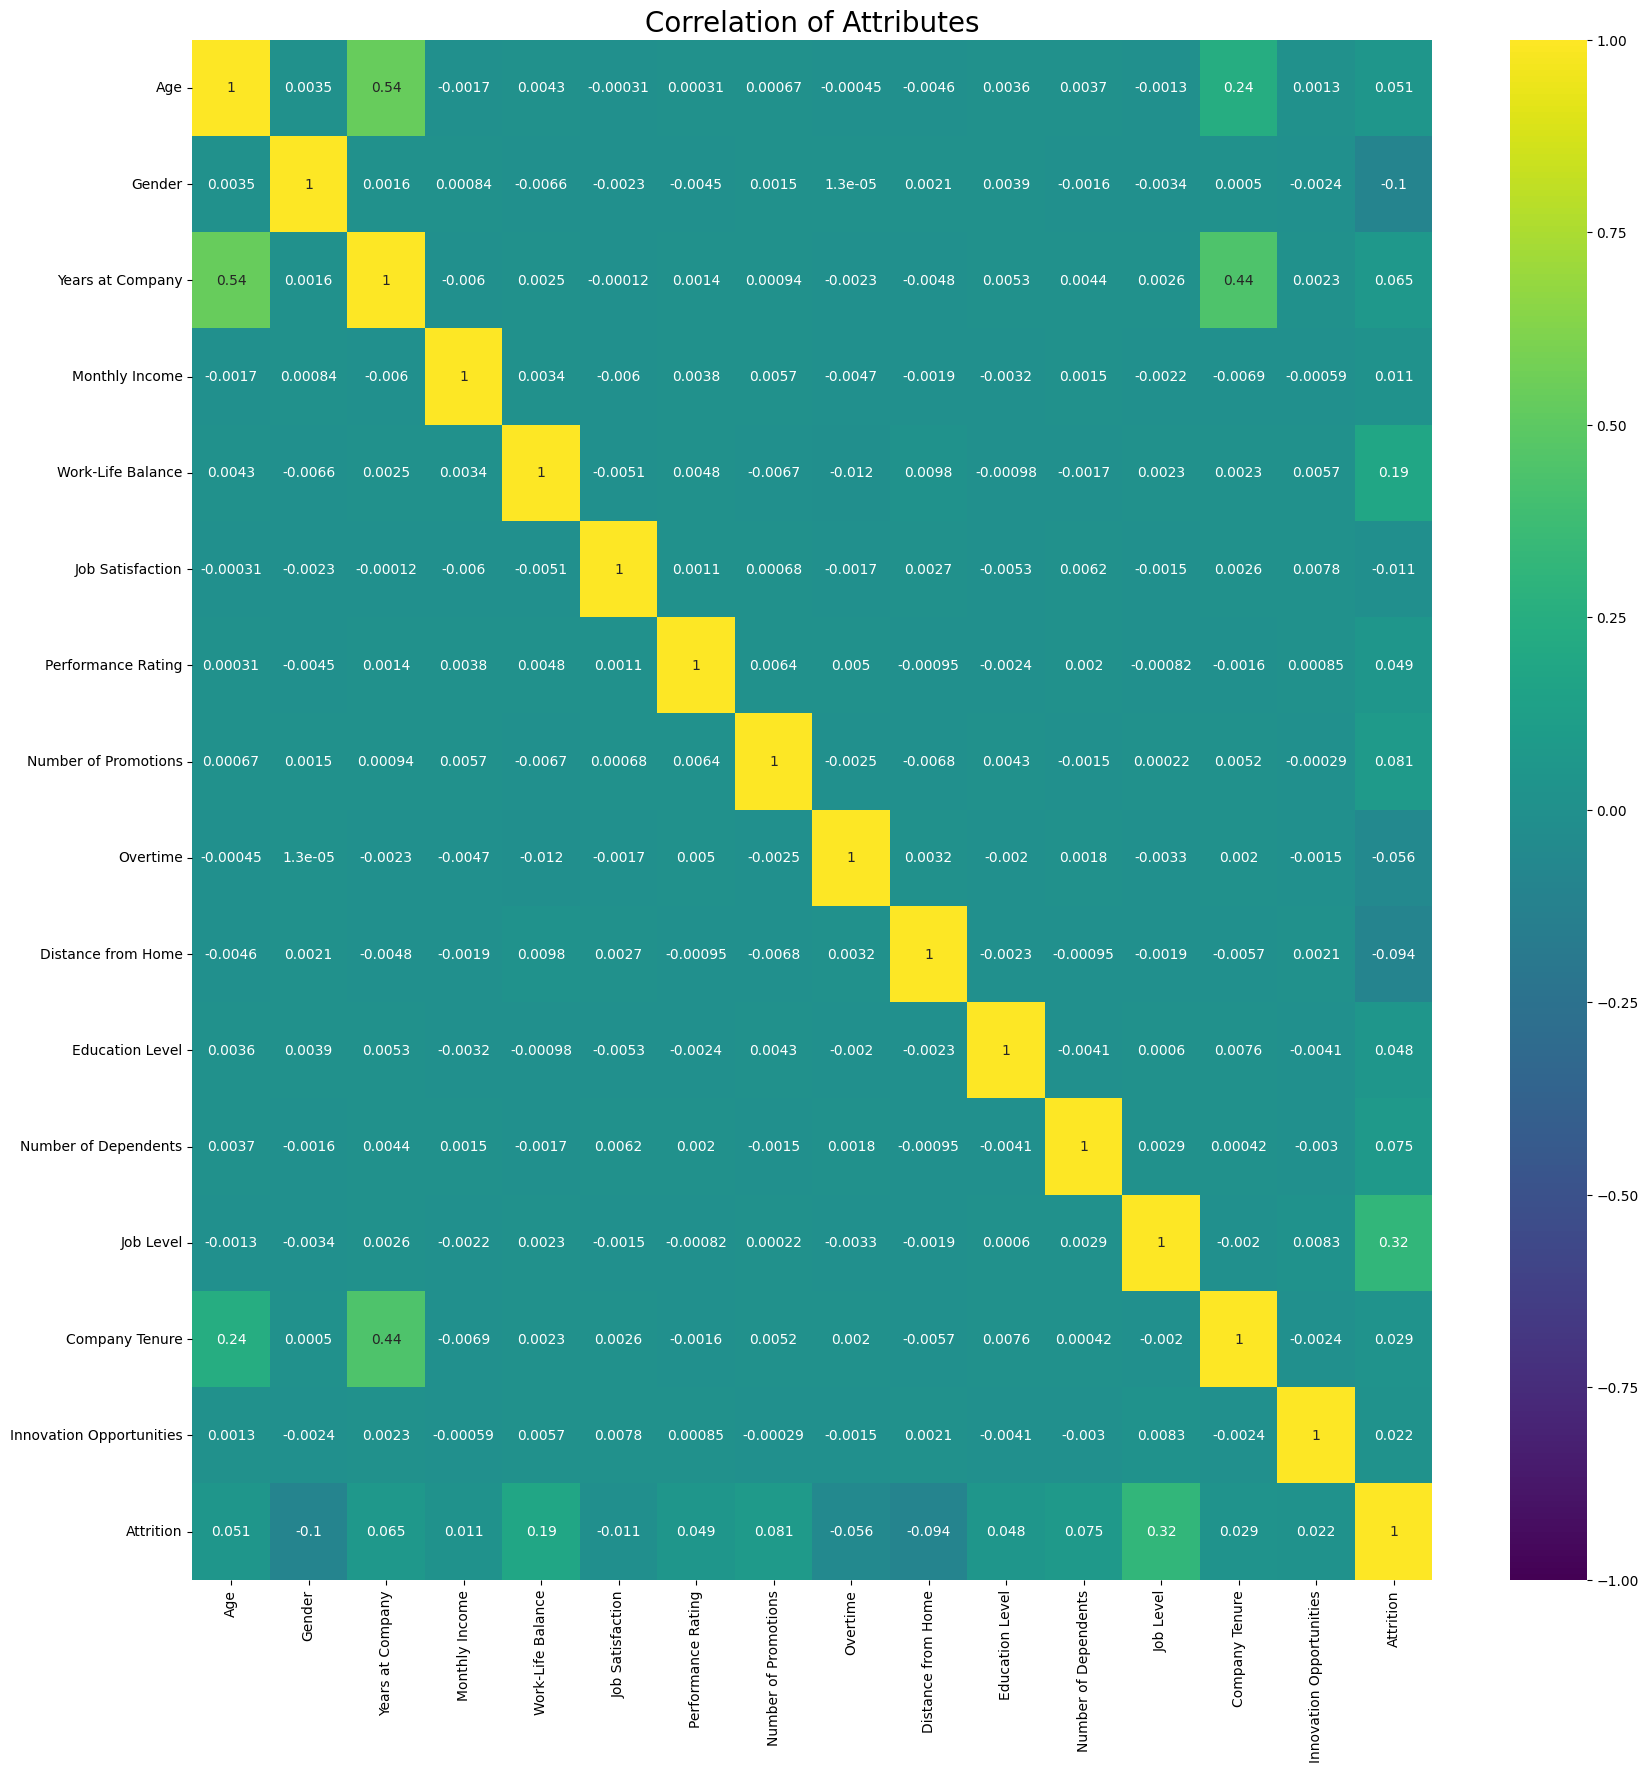

In [ ]:
emp_data = emp_data.drop(columns=['Employee ID'])

num_cols = [n for n in emp_data.columns if emp_data[n].dtypes!='O']
colormap = plt.cm.viridis
plt.figure(figsize=(20,20))
plt.title('Correlation of Attributes', size=20)
ax = sns.heatmap(emp_data[num_cols].corr(), cmap=colormap, annot=True, vmin=-1, vmax=1)
plt.show()